# Computer Vision Project about brain-tumor classification

### Let's begin by importing some necessary modules and functions

In [2]:
import io
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from huggingface_hub import notebook_login

from datasets import load_dataset, DatasetDict
from transformers import AutoImageProcessor, ViTForImageClassification
from transformers import Trainer, TrainingArguments
import evaluate
import torchvision.transforms as T


# Optional: Login für späteres Upload (nicht zwingend notwendig)
# notebook_login()

In [ ]:
#optional für mich zu sehen wie viele Bilder ich in beiden Kategorien habe
from collections import Counter
import os

# Verzeichnis mit Originalbildern (angepasst an meinen Pfad)
base_dir = "brain-tumor"

# Zähle Bilder pro Klasse
class_counts = {}
for class_dir in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_dir)
    if os.path.isdir(class_path):
        num_images = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        class_counts[class_dir] = num_images

print("Bilder pro Klasse:", class_counts)


Bilder pro Klasse: {'no': 1215, 'yes': 1469}


In [23]:
from huggingface_hub import notebook_login
notebook_login()


### load image classification dataset

In [4]:
from datasets import load_dataset

# lokalen Bilder-Ordner (mit yes/no Unterordnern) laden
dataset = load_dataset("imagefolder", data_dir="brain-tumor")

# Labels prüfen
labels = dataset["train"].unique("label")
print(len(labels), labels)

# Beispielbild anzeigen
print(dataset["train"][0])


Resolving data files:   0%|          | 0/2684 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

2 [0, 1]
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=L size=630x630 at 0x7F92E6477370>, 'label': 0}


### some sample images from my dataset

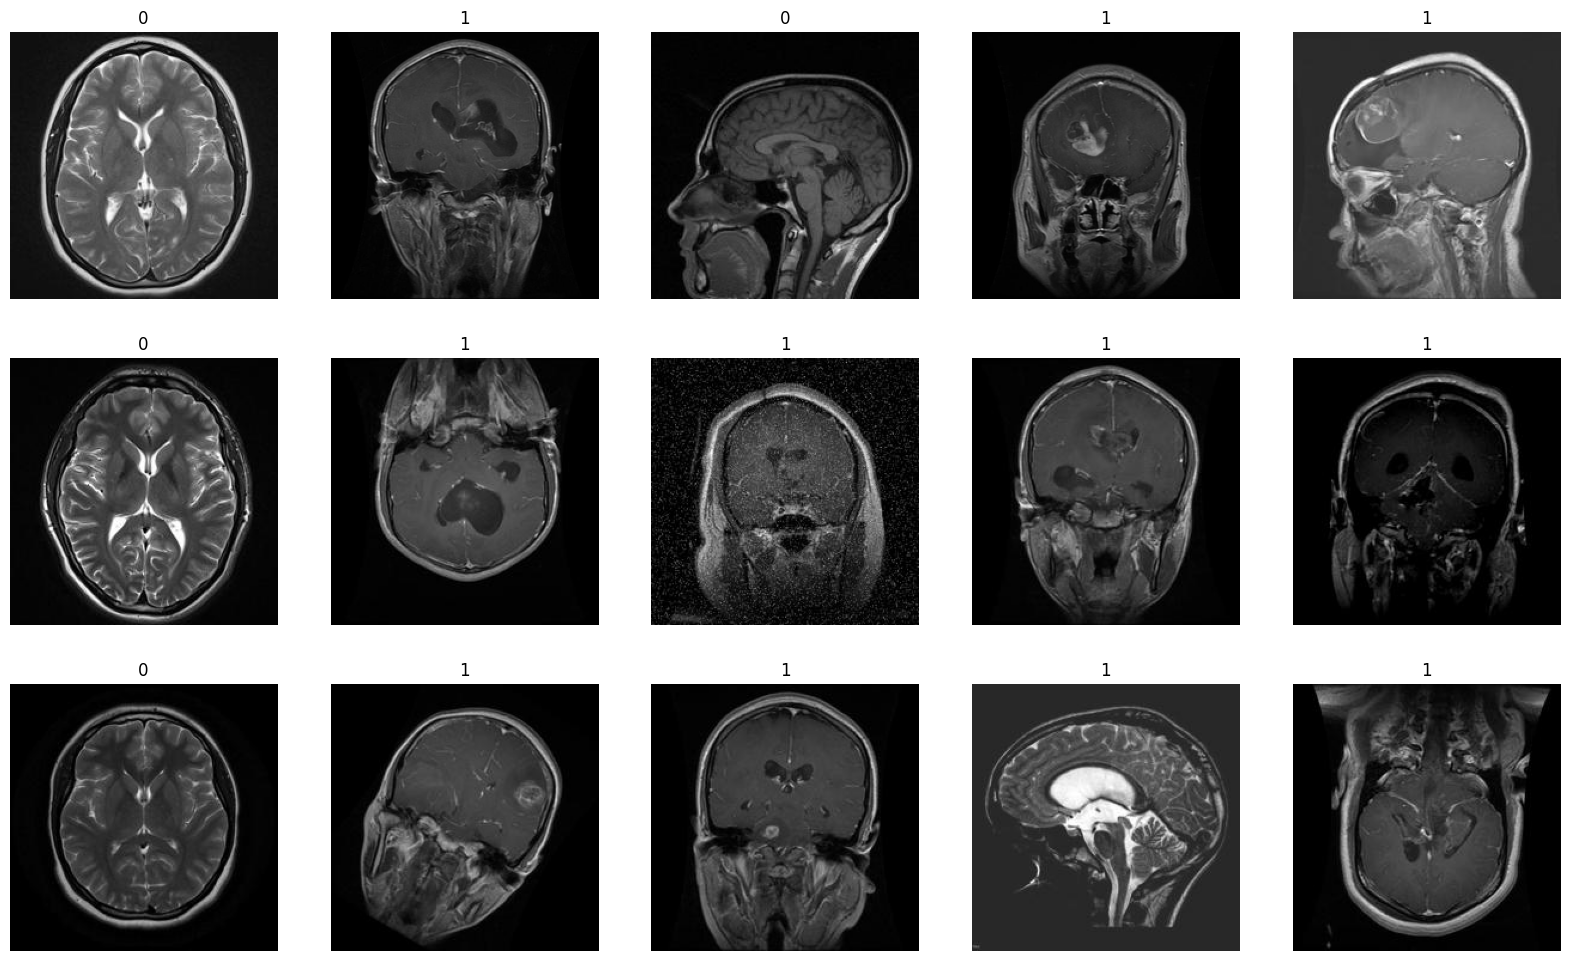

In [5]:
def show_samples(ds, rows=3, cols=5):
    samples = ds.shuffle(seed=42).select(np.arange(rows * cols))
    fig = plt.figure(figsize=(cols * 4, rows * 4))

    for i in range(rows * cols):
        img = samples[i]['image']
        label = samples[i]['label']
        fig.add_subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(labels[label])
        plt.axis('off')

show_samples(dataset['train'], rows=3, cols=5)


### Preprocessing my dataset

In [6]:
from datasets import DatasetDict

# Schritt 1: Aufteilen in 80% Training, 20% Evaluation
split_dataset = dataset['train'].train_test_split(test_size=0.2, seed=42)

# Schritt 2: Die 20% Evaluation aufteilen in 50% Validation, 50% Test
eval_dataset = split_dataset['test'].train_test_split(test_size=0.5, seed=42)

# Schritt 3: Zusammensetzen in ein DatasetDict
our_dataset = DatasetDict({
    'train': split_dataset['train'],
    'validation': eval_dataset['train'],
    'test': eval_dataset['test']
})

# Optional: Übersicht anzeigen
our_dataset


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2147
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 268
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 269
    })
})

In [7]:

#optional um zu sehen wie viel bilder drin sind
print(len(our_dataset["train"]))
print(len(our_dataset["validation"]))
print(len(our_dataset["test"]))


2147
268
269


In [8]:
# Testen, ob in allen Splits beide Klassen (yes/no) enthalten sind
for split in ['train', 'validation', 'test']:
    labels_in_split = set(example['label'] for example in our_dataset[split])
    print(f"{split}: {len(labels_in_split)} Klassen")


train: 2 Klassen
validation: 2 Klassen
test: 2 Klassen


In [9]:
# Holt die Klassenlabels (['no', 'yes']) aus dem Datensatz
labels = our_dataset["train"].features["label"].names

# Erstellt Zuordnungen
label2id = {c: idx for idx, c in enumerate(labels)}
id2label = {idx: c for idx, c in enumerate(labels)}


### Image Processor

In [10]:
# den Image Processor laden
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
processor


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

### Augmentieren um mehrere Varianten von einem Bild zu haben

In [11]:
# Einheitliche Augmentierung für alle Bilder im Training
train_augmentation = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
])

#Transformationsfunktion mit Augmentation

def train_transforms(batch):
    augmented_images = [train_augmentation(img.convert("RGB")) for img in batch['image']]
    inputs = processor(images=augmented_images, return_tensors="pt")
    inputs["labels"] = batch["label"]
    return inputs



# Transformationsfunktion für Validierung & Test – keine Augmentierung

def transforms(batch):
    images = [img.convert("RGB") for img in batch['image']]
    inputs = processor(images=images, return_tensors="pt")
    inputs["labels"] = batch["label"]
    return inputs


In [12]:
# Zuerst Standard-Transforms auf alle Splits anwenden
processed_dataset = our_dataset.with_transform(transforms)

# Dann nur für das Training die Augmentation aktivieren
processed_dataset['train'] = processed_dataset['train'].with_transform(train_transforms)


In [13]:
processed_dataset


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2147
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 268
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 269
    })
})

### Beispiel für Bilder mit Augmentation 

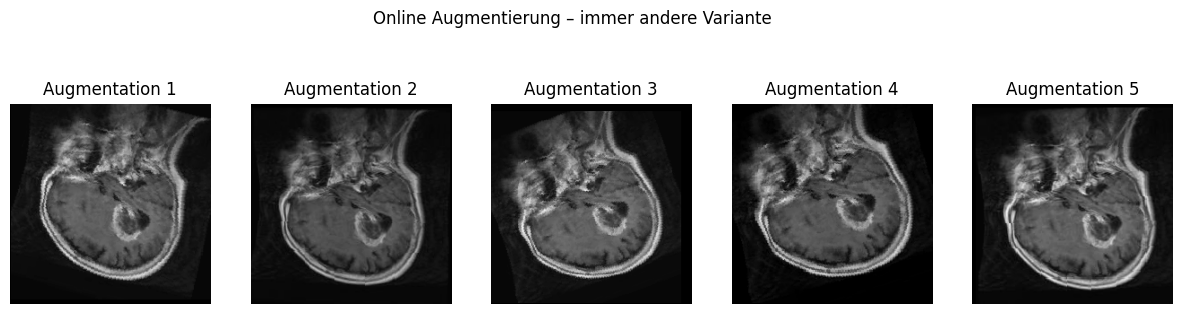

In [14]:
#optional für mich um zu sehen wie die Bilder augmentiert werden
# Ein Beispielbild holen
from PIL import Image
img = our_dataset['train'][0]['image'].convert("RGB")

# Mehrfach augmentieren
fig, axs = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    augmented = train_augmentation(img)
    axs[i].imshow(augmented)
    axs[i].set_title(f"Augmentation {i+1}")
    axs[i].axis('off')
plt.suptitle("Online Augmentierung – immer andere Variante")
plt.show()


### Data Collation

In [15]:
# Benutzerdefinierte Collate-Funktion für den DataLoader
    # Diese Funktion wird verwendet, um mehrere einzelne Beispiele (batch) zu einem Mini-Batch zu verarbeiten,
    # der an das Modell übergeben werden kann.
def collate_fn(batch):
    return {
        'pixel_values': torch.stack([x['pixel_values'] for x in batch]),
        'labels': torch.tensor([x['labels'] for x in batch])         # 'labels' enthält die Zielklassen der Beispiele (0 oder 1).
    }


### calculate the metrics


In [16]:
import evaluate

# das Accuracy-Metrik-Modul laden
accuracy = evaluate.load('accuracy')

# die Auswertungsfunktion definieren
def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=1)   # Vorhersagen: Index des höchsten Logit-Wertes entspricht der vorhergesagten Klasse
    score = accuracy.compute(predictions=predictions, references=labels)  # Accuracy berechnen: Vergleich der Vorhersagen mit den tatsächlichen Labels
    return score


### Loading the Model

In [17]:
# Das vortrainierte ViT-Modell für Bildklassifikation aus der Transformers-Bibliothek importieren
from transformers import ViTForImageClassification

# Das ViT-Modell laden und an die aktuelle Klassifikationsaufgabe anpassen
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',       #  Vortrainiertes Vision Transformer Modell von Google
    num_labels=len(label2id),            #  Anzahl der Klassen im aktuellen Datensatz (z. B. 2 für Tumor/Kein Tumor)
    id2label=id2label,                   #  Mapping von numerischen IDs zu Klassennamen (z. B. {0: "no", 1: "yes"})
    label2id=label2id,                   #  Umgekehrtes Mapping (z. B. {"no": 0, "yes": 1})
    ignore_mismatched_sizes=True         #  Erlaubt kleine Unterschiede in der Modellstruktur (z. B. bei geänderter Anzahl Klassen)
)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Here's the architecture of my model

In [18]:
model

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

### Freeze the parameters

Da wir nicht das gesamte Modell aktualisieren wollen, können wir alle Parameter einfrieren, außer der neuen Klassifikationsschicht.
Das erreichen wir, indem wir für die Parameter jeder Schicht requires_grad = False setzen – dadurch werden sie beim Training nicht mehr angepasst.

In [19]:
for name, p in model.named_parameters():
    if not name.startswith('classifier'):
        p.requires_grad = False


### Check the number of total parameters and of trainable ones
Wir können überprüfen, wie viele Parameter das Modell insgesamt hat – und wie viele davon tatsächlich trainiert werden.

In [20]:
num_params = sum([p.numel() for p in model.parameters()])
trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])

print(f"{num_params = :,} | {trainable_params = :,}")


num_params = 85,800,194 | trainable_params = 1,538


### Let's commence the training 🚀️

In [21]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./vit-base-brain-tumor",  # Speicherort für Checkpoints
    per_device_train_batch_size=16,       # Batch-Größe
    evaluation_strategy="epoch",          # Eval nach jeder Epoche
    save_strategy="epoch",  # Speichern nach jeder Epoche
    logging_strategy="epoch",  # Logge mindestens einmal pro Epoche              
    logging_steps=100,                    # Wie oft Logs erscheinen
    num_train_epochs=15,                   # Anzahl der Trainingsdurchläufe
    learning_rate=2e-5,                   # Lernrate
    save_total_limit=2,                   # Max. Anzahl gespeicherter Modelle
    remove_unused_columns=False,          # Wichtig für Image Inputs
    push_to_hub=True,                     # Optional: Modell zu Hugging Face hochladen
    report_to='tensorboard',              # Visualisierung mit TensorBoard
    load_best_model_at_end=True,          # Bestes Modell nach Training verwenden
    run_name="vit-brain-tumor-transferlearning"  # Name für TensorBoard / Logs
)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [24]:
# Den Trainer aus der Hugging Face Transformers-Bibliothek importieren
from transformers import Trainer

# Einen Trainer erstellen, der das Modell trainiert und validiert
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,  # Collate-Funktion zum Zusammenstellen der Mini-Batches
    compute_metrics=compute_metrics,        #Funktion zur Berechnung der Evaluationsmetriken (z. B. Accuracy)
    train_dataset=processed_dataset["train"],    #Trainingsdaten
    eval_dataset=processed_dataset["validation"],   #Val Daten zur Bewertung während Training
    tokenizer=processor   #Bildprozessor
)


/tmp/ipykernel_1808/3789139693.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [25]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.826400,0.690421,0.570896
2,0.669200,0.591798,0.731343
3,0.558400,0.528117,0.783582
4,0.499300,0.485088,0.832090
5,0.455400,0.455448,0.832090
6,0.423700,0.434515,0.824627
7,0.403500,0.418333,0.824627
8,0.386100,0.406605,0.832090
9,0.379300,0.397585,0.843284
10,0.367800,0.389822,0.843284


TrainOutput(global_step=2025, training_loss=0.44975864740065585, metrics={'train_runtime': 322.4305, 'train_samples_per_second': 99.882, 'train_steps_per_second': 6.28, 'total_flos': 2.4956295255379354e+18, 'train_loss': 0.44975864740065585, 'epoch': 15.0})

### evaluating on my test dataset

In [27]:
trainer.evaluate(processed_dataset['test'])


{'eval_loss': 0.3678012490272522,
 'eval_accuracy': 0.8698884758364313,
 'eval_runtime': 1.7241,
 'eval_samples_per_second': 156.023,
 'eval_steps_per_second': 19.72,
 'epoch': 15.0}

### let's look at some of the predictions made by my new model!

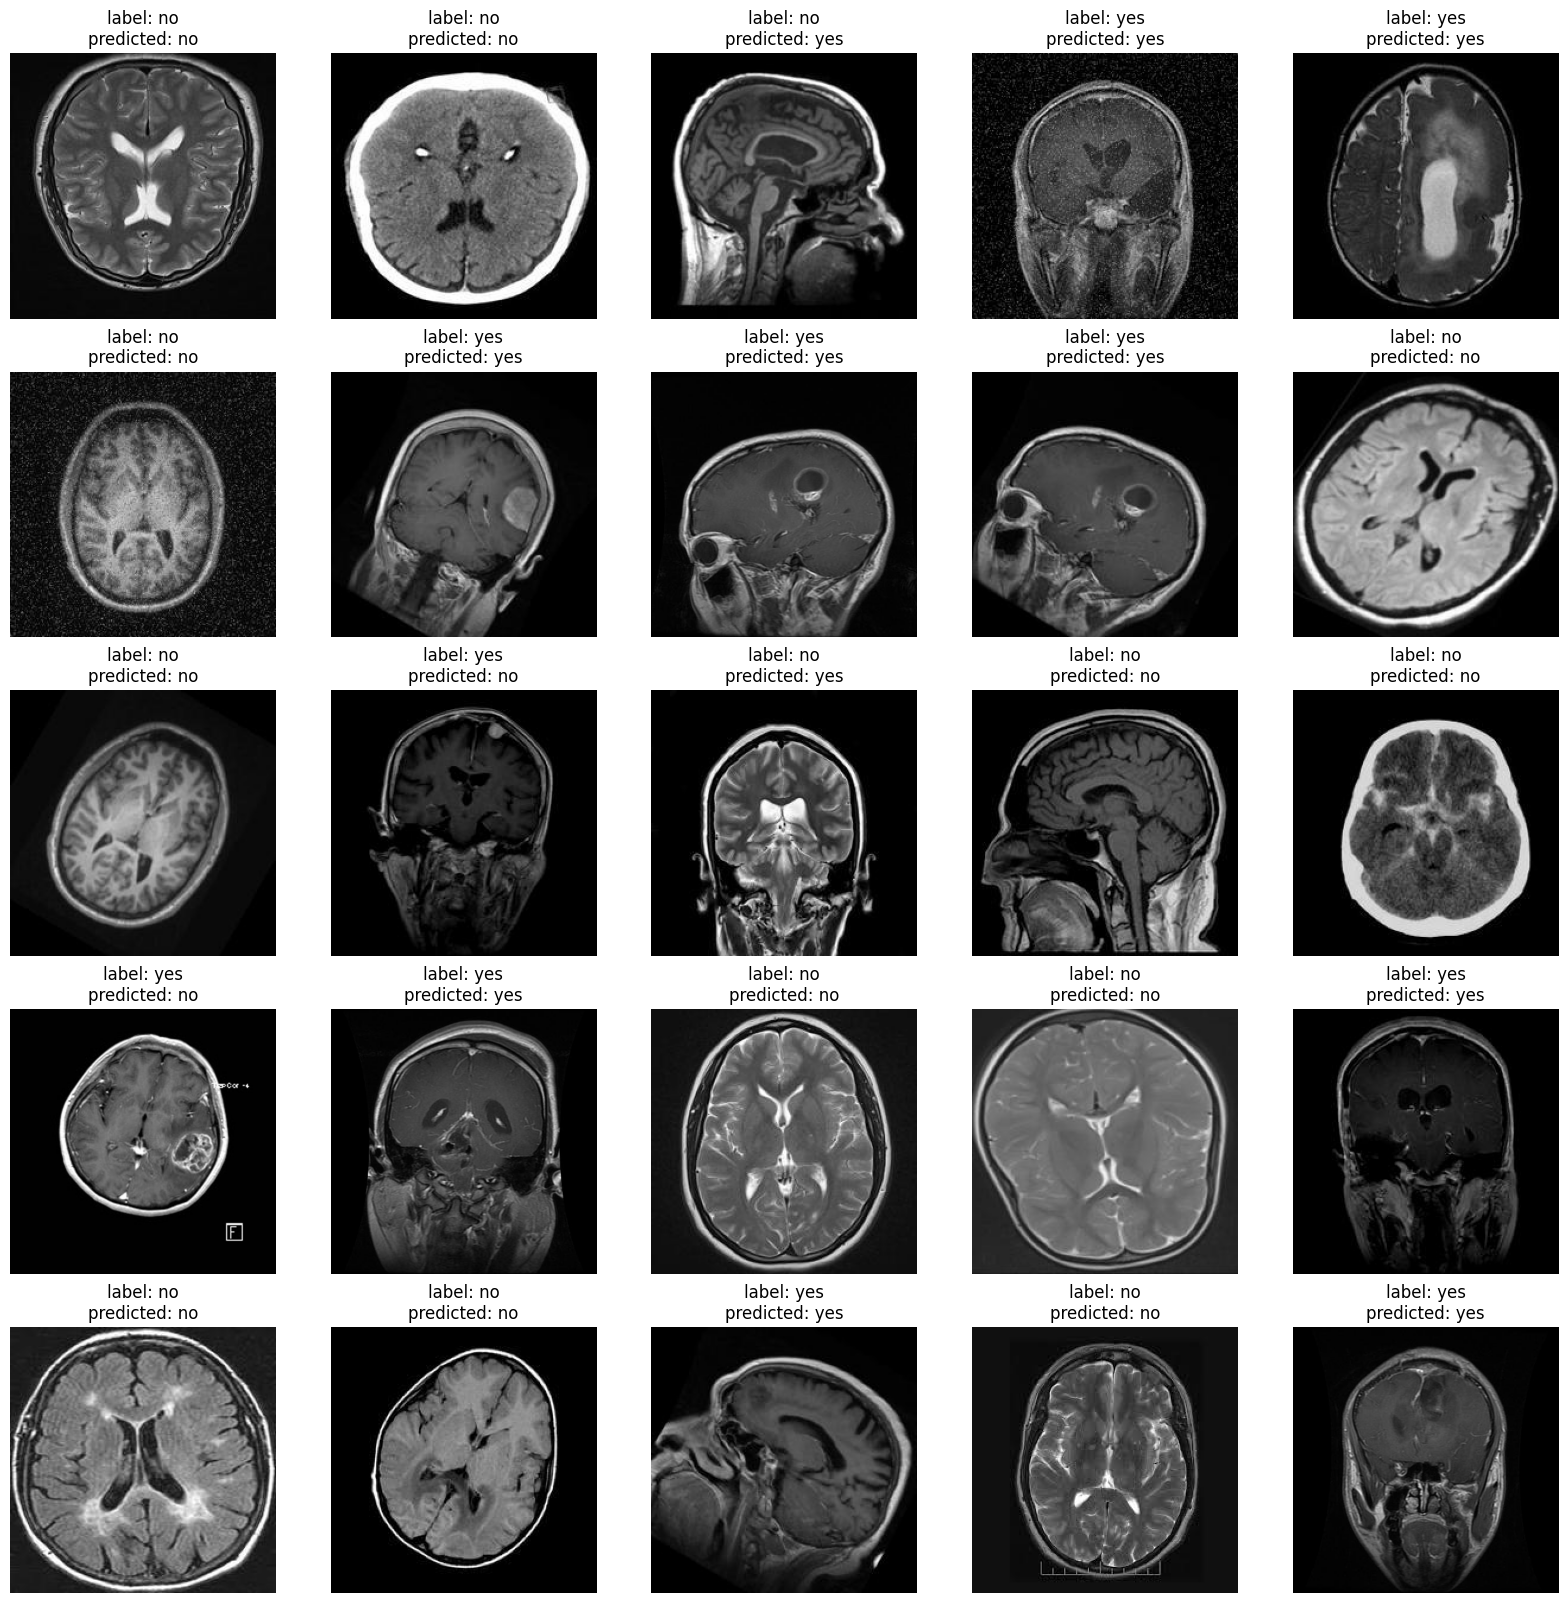

In [28]:
def show_predictions(rows, cols):
    # Zufällige Auswahl von Bildern aus dem Testset
    samples = our_dataset['test'].shuffle(seed=42).select(np.arange(rows * cols))
    
    # Bilder vorbereiten (transformieren)
    processed_samples = samples.with_transform(transforms)
    
    # Vorhersagen berechnen (logits → argmax → predicted labels)
    predictions = trainer.predict(processed_samples).predictions.argmax(axis=1)
    
    # Bilder anzeigen mit Titel: echtes Label + Vorhersage
    fig = plt.figure(figsize=(cols * 4, rows * 4))
    for i in range(rows * cols):
        img = samples[i]['image']  # Bereits PIL.Image
        prediction = predictions[i]
        label = f"label: {id2label[samples[i]['label']]}\npredicted: {id2label[prediction]}"
        fig.add_subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')

# Funktion aufrufen
show_predictions(rows=5, cols=5)


### Confusion Matrix

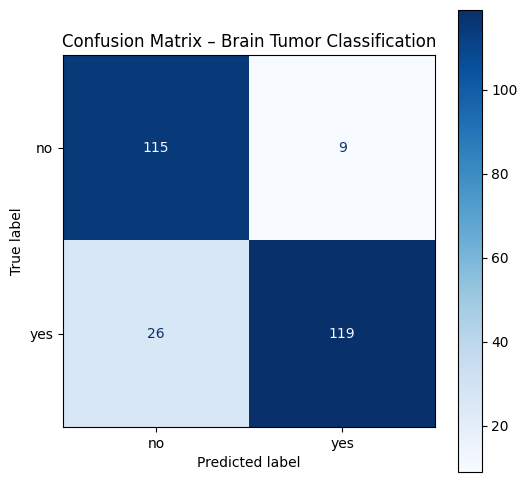

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Vorhersagen auf dem Testset holen
predictions = trainer.predict(processed_dataset["test"])
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Confusion Matrix berechnen
cm = confusion_matrix(y_true, y_pred)

# Labels in der richtigen Reihenfolge
labels = processed_dataset["test"].features["label"].names

# Matrix anzeigen
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix – Brain Tumor Classification")
plt.show()


### Distribution of Labels

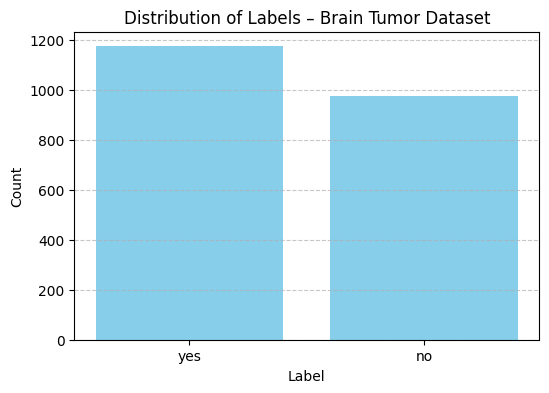

In [31]:
import matplotlib.pyplot as plt
from collections import Counter

# Labels im Trainingsdatensatz extrahieren
train_labels = [example['label'] for example in our_dataset['train']]

# Namen der Klassen holen
label_names = our_dataset['train'].features['label'].names

# Zählen Anzahl je Label (0/1 → no/yes)
label_counts = Counter(train_labels)

# Vorbereitung für Plot
labels = [label_names[i] for i in label_counts.keys()]
counts = list(label_counts.values())

# Diagramm zeichnen
plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color='skyblue')
plt.title("Distribution of Labels – Brain Tumor Dataset")
plt.xlabel("Label")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### My model works really well! Let's save it and also push it to Hugging Face model hub!

In [33]:
kwargs = {
    "finetuned_from": model.config._name_or_path,
    "dataset": "brain-tumor (lokal)",  
    "tasks": "image-classification",
    "tags": ["image-classification", "brain-tumor", "medical-imaging"],
}


In [34]:
# Modell lokal speichern
trainer.save_model()

# Modell zu Hugging Face hochladen
trainer.push_to_hub("🧠 Brain Tumor Classifier", **kwargs)


events.out.tfevents.1748096419.ip-10-192-11-175.1808.1:   0%|          | 0.00/734 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Tharsana/vit-base-brain-tumor/commit/b5663654cc006c7fc2ee94446fc4804bf9fe6c39', commit_message='🧠 Brain Tumor Classifier', commit_description='', oid='b5663654cc006c7fc2ee94446fc4804bf9fe6c39', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Tharsana/vit-base-brain-tumor', endpoint='https://huggingface.co', repo_type='model', repo_id='Tharsana/vit-base-brain-tumor'), pr_revision=None, pr_num=None)